Comparing with SMC-ABC

In [1]:
%pip install pyabc numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import pyabc
import matplotlib.pyplot as plt
from pyabc.visualization import plot_kde_matrix, plot_epsilons
from pyabc.sampler import SingleCoreSampler


In [15]:
# ==========================================
# 1. Real Data Loading
# ==========================================
import pandas as pd
import numpy as np
import os
import tempfile

# Load your collected sensor data here. 
file_path = './data/sequence_2/sequence_2_timeseries.csv'
min_time = 20.0  # Cutoff time from main.ipynb

try:
    df_data = pd.read_csv(file_path)
    
    # --- Minimum Time Filter (from main.ipynb) ---
    original_len = len(df_data)
    df_data = df_data[df_data['relative_time_sec'] >= min_time].copy()
    print(f"Time trim: Removed {original_len - len(df_data)} frames prior to t={min_time:.2f}s")
    
    # Extract arrays
    time_steps = df_data['relative_time_sec'].values
    sensor_data = df_data['max_temperature_kelvin'].values
    
    # CRITICAL: Shift the time series so it starts at t=0
    # This ensures newtons_cooling() correctly uses T0 at the first time step
    time_steps = time_steps - time_steps[0]
    
    print(f"Successfully loaded {len(time_steps)} data points.")
except FileNotFoundError:
    print(f"Warning: '{file_path}' not found. Generating a dummy dataset so the script can run.")

# Set the initial temperature to the very first sensor reading (after the trim)
T0 = sensor_data[0]

# --- NEW NORMALIZATION CODE ---
# Calculate scaling constants from the observed data
data_mean = np.mean(sensor_data)
data_std = np.std(sensor_data)

# Normalize the observed data
sensor_data_norm = (sensor_data - data_mean) / data_std

# The updated mathematical equation with a t_0 shift
#def newtons_cooling(k, T_env, t, t_0, T_initial):
#    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

# Without t_0
def newtons_cooling(k, T_env, t, T_initial):
    """Newton's Law of Cooling assuming the recording starts at t=0"""
    return T_env + (T_initial - T_env) * np.exp(-k * t)

# Package the real observations for pyabc
observation = {"temperature_curve": sensor_data_norm}

Time trim: Removed 3 frames prior to t=20.00s
Successfully loaded 24 data points.


In [26]:
# ==========================================
# 2. SMC-ABC Configuration
# ==========================================
prior = pyabc.Distribution(
    k=pyabc.RV("uniform", 0.03, 0.05),
    T_env=pyabc.RV("uniform", 300.0, 310.0),
    #t_0=pyabc.RV("uniform", -5.0, 5.0),
    sigma=pyabc.RV("uniform", 0.1, 5.0), # Search for sensor noise between 0.1 and 5 degrees
    T_initial=pyabc.RV("uniform", 300.0, 350.0)
)

'''
def newtons_cooling(k, T_env, t, t_0, T_initial):
    """Newton's Law of Cooling with a time offset (t_0)"""
    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

'''

def newtons_cooling(k, T_env, t, T_initial):
    """Newton's Law of Cooling assuming the recording starts at t=0"""
    return T_env + (T_initial - T_env) * np.exp(-k * t)

'''
def abc_model(parameters):
    k_sim = parameters["k"]
    T_env_sim = parameters["T_env"]
    t_0_sim = parameters["t_0"]
    sigma_sim = parameters["sigma"]

    clean_curve = newtons_cooling(k_sim, T_env_sim, time_steps, t_0_sim, T0)

    # The model now outputs noisy synthetic data
    noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_steps))

    # --- NEW NORMALIZATION CODE ---
    # Normalize the simulated data using the OBSERVED mean and std
    noisy_curve_norm = (noisy_curve - data_mean) / data_std

    return {"temperature_curve": noisy_curve_norm}
'''
# Without t_0
def abc_model(parameters):
    k_sim = parameters["k"]
    T_env_sim = parameters["T_env"]
    sigma_sim = parameters["sigma"]
    T_initial_sim = parameters["T_initial"] 
    # t_0_sim is completely gone

    # Generate the curve using the fixed function
    clean_curve = newtons_cooling(k_sim, T_env_sim, time_steps, T_initial_sim)

    # Add the simulated noise
    noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_steps))

    # Normalize the simulated data (using constants calculated from your sensor data)
    noisy_curve_norm = (noisy_curve - data_mean) / data_std

    # Return the normalized curve
    return {"temperature_curve": noisy_curve_norm}

In [27]:
# ==========================================
# 3. Execution (Fixed for Jupyter)
# ==========================================
# This is the line where we initialize ABCSMC and add the SingleCoreSampler
# Use an adaptive distance metric to prevent early steep drops from dominating

from pyabc.sampler import SingleCoreSampler

distance = pyabc.AdaptivePNormDistance(p=2)

abc = pyabc.ABCSMC(
    models=abc_model,
    parameter_priors=prior,
    distance_function=distance,
    population_size=pyabc.ConstantPopulationSize(200),
    sampler=SingleCoreSampler()
)

# Setup database logging
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "thermal_abc.db")

# Initialize and run
abc.new(db_path, observation)
print("Starting ABC-SMC run...")
history = abc.run(minimum_epsilon=0.5, max_nr_populations=20)
print("ABC-SMC run completed.")

ABC.History INFO: Start <ABCSMC id=7, start_time=2026-07-19 23:08:06>


ABC INFO: Calibration sample t = -1.


Starting ABC-SMC run...


ABC.Population INFO: Recording also rejected particles: True
ABC INFO: t: 0, eps: 1.22434926e+01.
ABC INFO: Accepted: 200 / 422 = 4.7393e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 8.14212744e+00.
ABC INFO: Accepted: 200 / 398 = 5.0251e-01, ESS: 1.4380e+02.
ABC INFO: t: 2, eps: 9.29040568e+00.
ABC INFO: Accepted: 200 / 418 = 4.7847e-01, ESS: 1.3359e+02.
ABC INFO: t: 3, eps: 9.38859616e+00.
ABC INFO: Accepted: 200 / 408 = 4.9020e-01, ESS: 1.6455e+02.
ABC INFO: t: 4, eps: 1.00921703e+01.
ABC INFO: Accepted: 200 / 414 = 4.8309e-01, ESS: 1.1335e+02.
ABC INFO: t: 5, eps: 8.77812558e+00.
ABC INFO: Accepted: 200 / 489 = 4.0900e-01, ESS: 7.2957e+01.
ABC INFO: t: 6, eps: 7.40769302e+00.
ABC INFO: Accepted: 200 / 426 = 4.6948e-01, ESS: 1.2630e+02.
ABC INFO: t: 7, eps: 7.00721405e+00.
ABC INFO: Accepted: 200 / 402 = 4.9751e-01, ESS: 1.3533e+02.
ABC INFO: t: 8, eps: 5.90019671e+00.
ABC INFO: Accepted: 200 / 479 = 4.1754e-01, ESS: 1.0613e+02.
ABC INFO: t: 9, eps: 5.81045344e+00.
ABC INFO: Accepted: 

ABC-SMC run completed.


In [28]:
def mode(arr):
    """Compute the mode of an array."""

    vals, counts = np.unique(arr, return_counts=True)
    mode_value = vals[np.argmax(counts)]

    return mode_value

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_posterior_predictive(history, t_real, temp_real, T0, num_samples=200):
    df, w = history.get_distribution(m=0, t=history.max_t)
    sample_indices = np.random.choice(len(df), size=num_samples, p=w)
    
    plt.figure(figsize=(10, 6))
    
    first_curve = True
    for idx in sample_indices:
        row = df.iloc[idx]
        k_sample = row['k']
        T_env_sample = row['T_env']
        t_0_sample = row['t_0']  # Extract the learned time offset
        
        # Run the model with the time shift
        temp_pred = newtons_cooling(k_sample, T_env_sample, t_real, t_0_sample, T0)

        if first_curve:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05, label='Posterior Predictive')
            first_curve = False
        else:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05)
            
    plt.scatter(t_real, temp_real, color='black', s=15, zorder=5, label='Real Sensor Data')
    
    # Plot the mean curve
    k_mean = np.average(df['k'], weights=w)
    T_env_mean = np.average(df['T_env'], weights=w)
    #t_0_mean = np.average(df['t_0'], weights=w)
    T_0_mean = np.average(df['T_initial'], weights=w)
    sigma_mean = np.average(df['sigma'], weights=w)
    temp_mean = newtons_cooling(k_mean, T_env_mean, t_real, t_0_mean, T0)
    print("k_mean:", k_mean)
    print("T_env_mean:", T_env_mean)
    print("t_0_mean:", t_0_mean)
    print("T_0_mean:", T_0_mean)
    print("sigma_mean:", sigma_mean)

    k_mode = mode(df['k'])
    T_env_mode = mode(df['T_env'])
    t_0_mode = mode(df['t_0']) 
    T_0_mode = mode(df['T_initial'])
    sigma_mode = mode(df['sigma'])

    print("k_mode:", k_mode)
    print("T_env_mode:", T_env_mode)
    print("t_0_mode:", t_0_mode)
    print("T_0_mode:", T_0_mode)
    print("sigma_mode:", sigma_mode)
    
    plt.plot(t_real, temp_mean, color='red', linestyle='--', linewidth=2, 
             label=f'Mean Model (t_0={t_0_mean:.2f}s)', zorder=6)
    
    plt.title("Posterior Predictive Check with Time Offset ($t_0$)", fontsize=14)
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Temperature (Kelvin)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

In [32]:
plot_posterior_predictive(history, time_steps, sensor_data, T0, num_samples=100)

KeyError: 't_0'

<Figure size 1000x600 with 0 Axes>

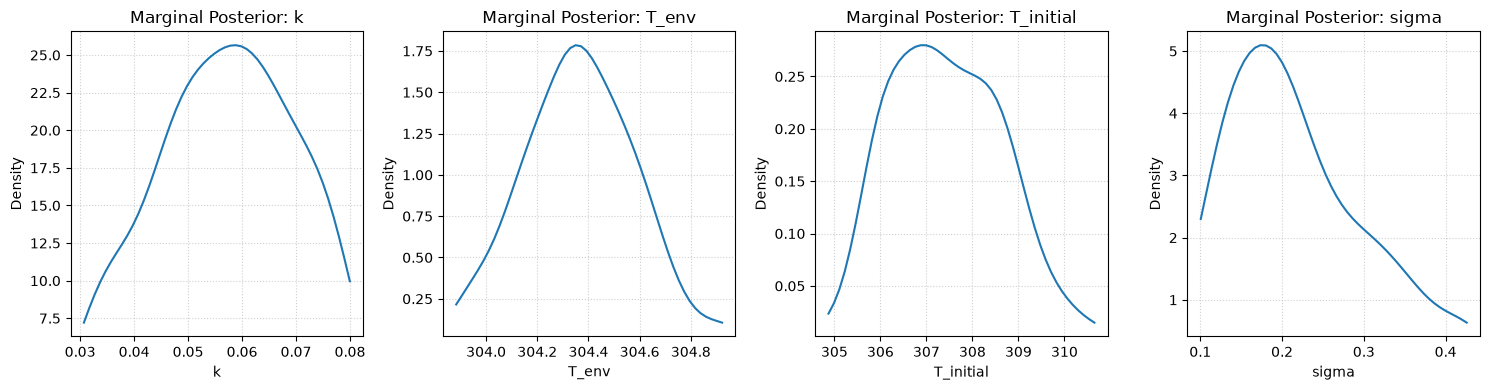

In [33]:
'''
from pyabc.visualization import plot_kde_1d

def plot_homoscedastic_marginals(history):
    df_params, w = history.get_distribution(m=0, t=history.max_t)
    
    params = ["k", "T_env", "t_0", "T_initial"]
    
    # Create a 1x3 grid
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    
    for i, param in enumerate(params):
        plot_kde_1d(df_params, w, x=param, ax=axes[i])
        axes[i].set_title(f"Marginal Posterior: {param}", fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_ylabel("Density")
        
    plt.tight_layout()
    plt.show()

# Execute using your existing history object
plot_homoscedastic_marginals(history)
'''

def plot_homoscedastic_marginals(history):
    df_params, w = history.get_distribution(m=0, t=history.max_t)
    
    # Removed "t_0" from this list
    params = ["k", "T_env", "T_initial", "sigma"] 
    
    fig, axes = plt.subplots(1, len(params), figsize=(15, 4))
    
    for i, param in enumerate(params):
        plot_kde_1d(df_params, w, x=param, ax=axes[i])
        axes[i].set_title(f"Marginal Posterior: {param}", fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_ylabel("Density")
        
    plt.tight_layout()
    plt.show()

plot_homoscedastic_marginals(history)